In [ ]:
# Copyright (c) TorchGeo Contributors. All rights reserved.
# Licensed under the MIT License.

# Aurora + ERA5 (WeatherBench 2)

This tutorial shows how to run Microsoft's [Aurora](https://github.com/microsoft/aurora) foundation model on [WeatherBench 2](https://weatherbench2.readthedocs.io/) ERA5 data using TorchGeo.

We will:

1. Stream WeatherBench 2 ERA5 directly from Google Cloud Storage with `torchgeo.datasets.WeatherBench2`.
2. Build a *global* Aurora-shaped batch with `torchgeo.datamodules.WeatherBench2AuroraDataModule`.
3. Run a zero-shot global rollout of the pretrained Aurora model.
4. Save the forecast as a Zarr store and reopen it with `WeatherBench2` (an `XarrayDataset` subclass) to extract a regional slice and compare it to ERA5 truth.

Aurora is most accurate when run *globally* — its encoder mixes information from across the planet, so a regional input loses the lateral-boundary signal the model relies on. We therefore drive the model with the full 0.25° grid and slice the *forecast* afterwards.

It's recommended to run this notebook on a machine with a GPU and at least ~16 GB of GPU RAM. The full global rollout takes a few seconds per step on a modern GPU and many minutes per step on CPU.

## Setup

Install TorchGeo with the dataset, model, and cloud-storage extras.

In [ ]:
%pip install "torchgeo[datasets,models]" microsoft-aurora fsspec gcsfs zarr

## Imports

In [3]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from aurora import rollout

from torchgeo.datamodules import (
    WeatherBench2AuroraDataModule,
    aurora_predictions_to_xarray,
)
from torchgeo.datasets import WeatherBench2
from torchgeo.models import Aurora_Weights, aurora_swin_unet

## Load the pretrained Aurora model

We use the pretrained checkpoint, which Microsoft trained on ERA5-like data. The fine-tuned `HRES_T0_AURORA` checkpoint was further trained on operational HRES analyses, which have a different distribution from ERA5 — so the pretrained backbone is the better match for zero-shot ERA5 forecasting.

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = aurora_swin_unet(weights=Aurora_Weights.HRES_T0_PRETRAINED_AURORA).to(device)
model.eval()
patch_size = Aurora_Weights.HRES_T0_PRETRAINED_AURORA.meta['patch_size']
print(f'Loaded Aurora pretrained (patch_size={patch_size}) on {device}.')

Loaded Aurora pretrained (patch_size=4) on cuda.


## Stream WeatherBench 2 ERA5 from GCS

TorchGeo's `WeatherBench2` is an `XarrayDataset` subclass that opens Zarr stores via `xarray.open_zarr`. It accepts local Zarr directories *or* `gs://` URIs — `fsspec`/`gcsfs` are pulled in lazily when needed.

The WeatherBench2 bucket is **public**. Without Google Application Default Credentials, `gcsfs` otherwise tries (slowly) to discover credentials; we pass `storage_options={'token': 'anon'}` so reads go straight to anonymous access.

For this tutorial we stream the public 0.25° store from
[`gs://weatherbench2/datasets/era5/`](https://weatherbench2.readthedocs.io/en/latest/data-guide.html#era5).
Set the `WEATHERBENCH2_ERA5_ZARR` environment variable to override the default if you have a local copy.

In [5]:
DEFAULT_STORE = (
    'gs://weatherbench2/datasets/era5/'
    '1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr'
)
weatherbench2_store = os.environ.get('WEATHERBENCH2_ERA5_ZARR', DEFAULT_STORE)
wb2_storage_options = (
    {'token': 'anon'} if str(weatherbench2_store).startswith('gs://') else None
)
print(f'WeatherBench2 store: {weatherbench2_store}')

WeatherBench2 store: gs://weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr


Construct the dataset with the variables Aurora needs. WeatherBench2 stores hold many derived variables we don't use here — passing an explicit `data_vars` list keeps memory bounded.

In [6]:
wb2 = WeatherBench2(
    paths=weatherbench2_store,
    storage_options=wb2_storage_options,
    data_vars=(
        '2m_temperature',
        '10m_u_component_of_wind',
        '10m_v_component_of_wind',
        'mean_sea_level_pressure',
        'temperature',
        'u_component_of_wind',
        'v_component_of_wind',
        'specific_humidity',
        'geopotential',
        'land_sea_mask',
        'soil_type',
        'geopotential_at_surface',
    ),
)
_, _, t_bounds = wb2.bounds
print(f'Time range in store: {t_bounds.start} to {t_bounds.stop}')

Time range in store: 1959-01-01 00:00:00 to 2023-01-10 18:00:00


## Build a global Aurora-shaped batch

Aurora's encoder needs the input grid `(H, W)` to have `W` divisible by the model's `patch_size`, with `H` either divisible by it or one larger (the model trims the southernmost row at runtime). The 0.25° global ERA5 grid is `721 × 1440`, which satisfies both constraints: `1440 % 4 == 0`, and Aurora handles the `721 → 720` height crop for us.

`WeatherBench2AuroraDataModule` already knows how to stack `context_steps + target_steps` windows along the time axis and produce an `aurora.Batch`. By default, it uses the dataset's full spatial bounds — exactly what Aurora wants for global rollouts — so we only need to pick a forecast initialization time. With `context_steps=2`, Aurora sees `T-6h` and `T0` as history. Pass `region=(xmin, ymin, xmax, ymax)` to override the default if you want a regional slice instead.

In [7]:
init_time = pd.Timestamp('2023-01-02 00:00')

infer_dm = WeatherBench2AuroraDataModule(
    paths=weatherbench2_store,
    start_time=init_time - pd.Timedelta('6h'),
    end_time=init_time + pd.Timedelta('6h'),
    timestep='6h',
    context_steps=2,
    target_steps=1,
    batch_size=1,
    num_workers=0,
    data_vars=wb2.data_vars,
    storage_options=wb2_storage_options,
)
infer_dm.setup('predict')
infer_out = next(iter(infer_dm.predict_dataloader()))
infer_batch = infer_out['batch']

H, W = infer_batch.surf_vars['2t'].shape[-2:]
print(f'Input grid: H={H}, W={W} (Aurora will crop H -> {H - H % patch_size}).')
print(f'Init time T0: {infer_batch.metadata.time[0]}')

Input grid: H=721, W=1440 (Aurora will crop H -> 720).
Init time T0: 2023-01-02 00:00:00


## Run the zero-shot global rollout

`aurora.rollout` is a generator: each iteration runs one forward pass and shifts its prediction into the history window for the next step. We materialize all predictions on CPU so that comparing lead times doesn't keep `steps × model_state` memory live on the GPU.

In [8]:
infer_batch = infer_batch.to(device)
steps = 4

with torch.inference_mode():
    preds = [p.to('cpu') for p in rollout(model, infer_batch, steps=steps)]

forecast_times = [init_time + pd.Timedelta('6h') * (i + 1) for i in range(steps)]
print(f'Generated {len(preds)} prediction step(s):')
for t in forecast_times:
    print(f'  {t}')

Generated 4 prediction step(s):
  2023-01-02 06:00:00
  2023-01-02 12:00:00
  2023-01-02 18:00:00
  2023-01-03 00:00:00


## Visualize the global forecast

We plot 2 m temperature at the +6 h and +24 h lead times. The first row of pixels in each map sits at 90°N (north pole row); longitudes go from 0°E (left) to 360°E (right). Aurora trims the southernmost row at runtime, so the y extent is `[-89.75°, 90°]`.

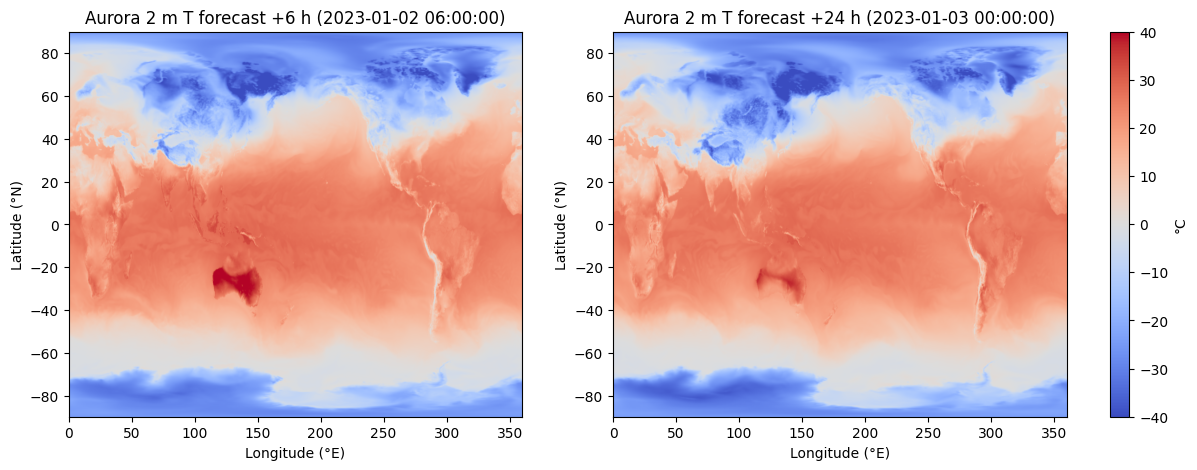

In [9]:
def kelvin_to_celsius(t: torch.Tensor) -> torch.Tensor:
    return t - 273.15


leads_to_show = [0, steps - 1]
fig, axes = plt.subplots(1, len(leads_to_show), figsize=(14, 5))
extent = (0.0, 360.0, -89.75, 90.0)
for ax, idx in zip(axes, leads_to_show):
    pred_2t = kelvin_to_celsius(preds[idx].surf_vars['2t'][0, 0]).numpy()
    im = ax.imshow(
        pred_2t, cmap='coolwarm', extent=extent, vmin=-40, vmax=40, aspect='auto'
    )
    hours = (idx + 1) * 6
    ax.set_title(f'Aurora 2 m T forecast +{hours} h ({forecast_times[idx]})')
    ax.set_xlabel('Longitude (°E)')
    ax.set_ylabel('Latitude (°N)')
fig.colorbar(im, ax=axes, fraction=0.04, pad=0.04, label='°C')
plt.show()

## Save the forecast and reopen it with `WeatherBench2`

`torchgeo.datamodules.aurora_predictions_to_xarray` packs the rollout into a WeatherBench-shaped :class:`xarray.Dataset` (WB2 variable names, `(time, latitude, longitude[, level])` coordinates). We persist it as a Zarr directory so the forecast becomes a first-class WB2-compatible product: anything that can read Zarr can read it, and TorchGeo's `WeatherBench2` (an `XarrayDataset` subclass) will let us slice it spatially / temporally without any additional plumbing.

After saving, we re-open the forecast through the same `WeatherBench2` class we used to stream public ERA5 from GCS, then extract the **continental U.S.** (`lon ∈ [235°, 285°]` ≡ `[-125°, -75°]`, `lat ∈ [25°, 50°]`) for *all* forecast lead times and compare it to the contemporaneous ERA5 truth via the same `[xmin:xmax:xres, ymin:ymax:yres, tmin:tmax:tres]` indexing API.

In [10]:
forecast_zarr = os.path.join(
    tempfile.mkdtemp(prefix='aurora_forecast_'), 'aurora_zero_shot.zarr'
)
forecast_ds = aurora_predictions_to_xarray(preds, init_time, timestep='6h')
forecast_ds.to_zarr(forecast_zarr, mode='w')
print(f'Wrote forecast to {forecast_zarr}')
print(forecast_ds)

Wrote forecast to /scratch/cnagda2/tmp/aurora_forecast_mk8aiq45/aurora_zero_shot.zarr
<xarray.Dataset> Size: 1GB
Dimensions:                  (time: 4, latitude: 720, longitude: 1440, level: 13)
Coordinates:
  * time                     (time) datetime64[us] 32B 2023-01-02T06:00:00 .....
  * latitude                 (latitude) float32 3kB 90.0 89.75 ... -89.5 -89.75
  * longitude                (longitude) float32 6kB 0.0 0.25 ... 359.5 359.8
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
Data variables:
    2m_temperature           (time, latitude, longitude) float32 17MB 247.1 ....
    10m_u_component_of_wind  (time, latitude, longitude) float32 17MB 0.997 ....
    10m_v_component_of_wind  (time, latitude, longitude) float32 17MB 2.098 ....
    mean_sea_level_pressure  (time, latitude, longitude) float32 17MB 1.034e+...
    temperature              (time, level, latitude, longitude) float32 216MB ...
    u_component_of_wind      (time, level, latitude

/u/cnagda2/.conda/envs/torchgeo/lib/python3.12/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [11]:
forecast_wb2 = WeatherBench2(
    paths=forecast_zarr,
    data_vars=('2m_temperature',),
)

xres, yres = forecast_wb2.res
us_xmin, us_ymin, us_xmax, us_ymax = 235.0, 25.0, 285.0, 50.0
t_first, t_last = forecast_times[0], forecast_times[-1]

forecast_us = forecast_wb2[
    us_xmin:us_xmax:xres, us_ymin:us_ymax:yres, t_first:t_last:1
]
era5_us = wb2[us_xmin:us_xmax:xres, us_ymin:us_ymax:yres, t_first:t_last:1]

forecast_2t = forecast_us['variables']['2m_temperature'].numpy() - 273.15
era5_2t = era5_us['variables']['2m_temperature'].numpy() - 273.15
residual = forecast_2t - era5_2t
mae_by_lead = np.mean(np.abs(residual), axis=(1, 2))
leads = [(i + 1) * 6 for i in range(steps)]

print(f'Aurora forecast region shape: {forecast_2t.shape}')
print(f'ERA5 truth region shape:      {era5_2t.shape}')
for hours, mae in zip(leads, mae_by_lead):
    print(f'  +{hours:3d} h   MAE = {mae:.2f} K')

Aurora forecast region shape: (4, 101, 201)
ERA5 truth region shape:      (4, 101, 201)
  +  6 h   MAE = 0.61 K
  + 12 h   MAE = 0.68 K
  + 18 h   MAE = 0.73 K
  + 24 h   MAE = 0.68 K


## Visualize the regional comparison and error growth

Below we plot, for the continental U.S.:

* Aurora's 2 m temperature at the longest lead time (`+24 h`),
* the matching ERA5 truth at the same timestamp,
* the residual (`Aurora − ERA5`) at `+24 h`, and
* the regional MAE as a function of forecast horizon — Aurora's error compounds with lead time, but stays small at `+6 h` and grows only modestly out to `+24 h`.

Both Aurora and ERA5 fields come from the same `WeatherBench2` indexing API — the only difference is whether the underlying Zarr store is the public ERA5 archive on GCS or the local forecast we just wrote.

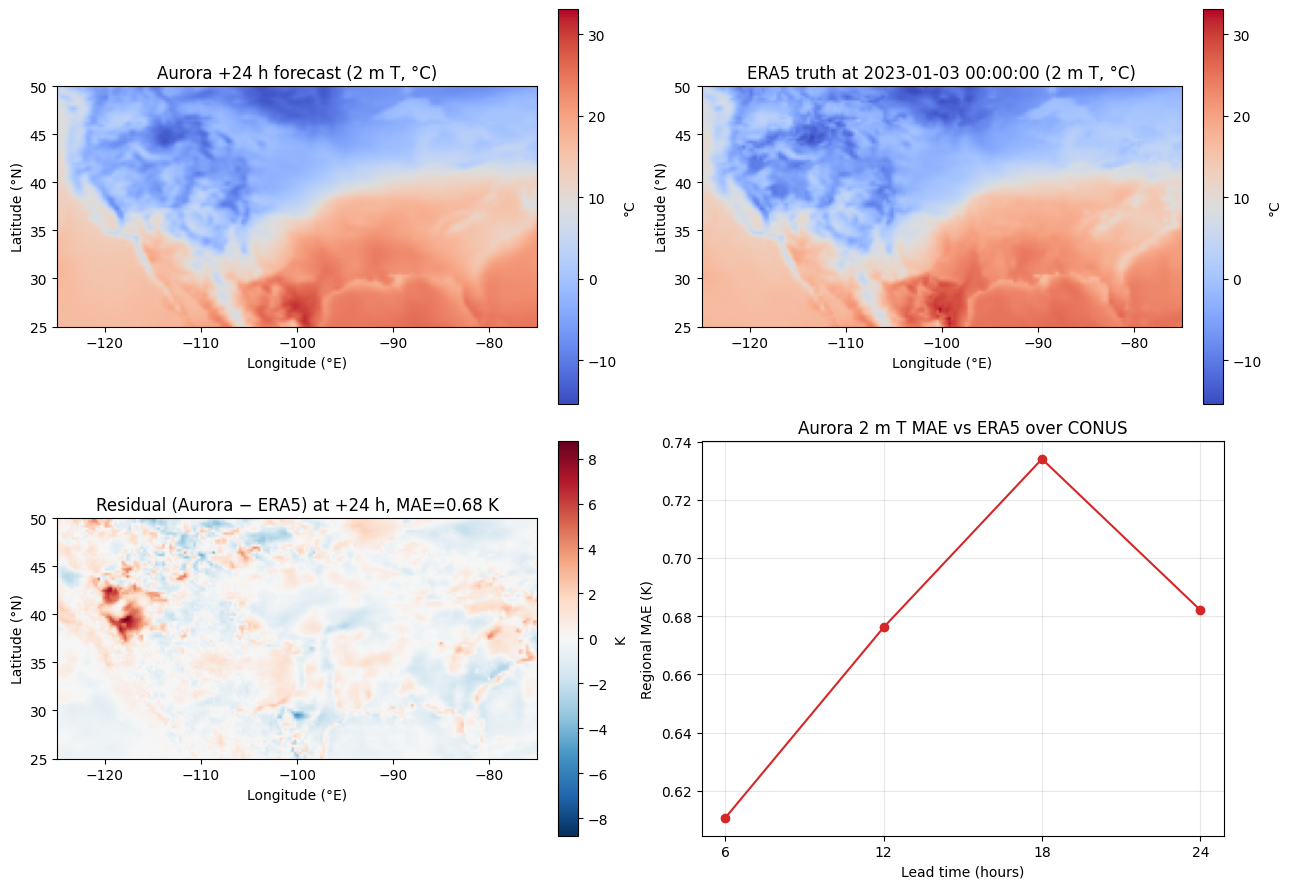

In [12]:
last = -1
extent = (us_xmin - 360, us_xmax - 360, us_ymin, us_ymax)
vmin = float(min(forecast_2t[last].min(), era5_2t[last].min()))
vmax = float(max(forecast_2t[last].max(), era5_2t[last].max()))
res_lim = float(np.max(np.abs(residual)))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ax = axes[0, 0]
im = ax.imshow(forecast_2t[last], cmap='coolwarm', vmin=vmin, vmax=vmax, extent=extent)
ax.set_title(f'Aurora +{leads[last]} h forecast (2 m T, °C)')
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.04, label='°C')

ax = axes[0, 1]
im = ax.imshow(era5_2t[last], cmap='coolwarm', vmin=vmin, vmax=vmax, extent=extent)
ax.set_title(f'ERA5 truth at {forecast_times[last]} (2 m T, °C)')
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.04, label='°C')

ax = axes[1, 0]
im = ax.imshow(
    residual[last], cmap='RdBu_r', vmin=-res_lim, vmax=res_lim, extent=extent
)
ax.set_title(f'Residual (Aurora − ERA5) at +{leads[last]} h, MAE={mae_by_lead[last]:.2f} K')
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.04, label='K')

ax = axes[1, 1]
ax.plot(leads, mae_by_lead, marker='o', color='C3')
ax.set_xticks(leads)
ax.set_xlabel('Lead time (hours)')
ax.set_ylabel('Regional MAE (K)')
ax.set_title('Aurora 2 m T MAE vs ERA5 over CONUS')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Where TorchGeo fits, and next steps

The TorchGeo pieces used in this tutorial are:

* [`torchgeo.datasets.WeatherBench2`](../api/datasets/weatherbench.rst) — an `XarrayDataset` subclass that streams Zarr stores (local or `gs://`) and slices them by `[lon:lat:time]`.
* [`torchgeo.datamodules.WeatherBench2AuroraDataModule`](../api/datamodules.rst) — a `NonGeoDataModule` that wraps the dataset into Aurora-shaped context windows, paired with `aurora_collate_fn` and `AuroraWeatherBench2Sequence`.
* [`torchgeo.models.aurora_swin_unet`](../api/models.rst) — a thin loader for Microsoft's Aurora pretrained checkpoints.

Notice that the *exact same* `WeatherBench2` class served two roles here: streaming public ERA5 from GCS, and slicing the freshly written local forecast Zarr. That's the value of the `XarrayDataset` abstraction — once your data lives in a Zarr (or other xarray-compatible) store, TorchGeo gives you spatial / temporal indexing for free.

Natural extensions:

* **More variables / different regions** — re-open the forecast Zarr or `wb2` and slice any bbox you like; you can also intersect `WeatherBench2` with other geospatial datasets via the `&` operator since it's a `GeoDataset`.
* **Longer rollouts** — increase `steps` in the `rollout` call to extend the forecast horizon. Errors compound with lead time, but Aurora was trained with rollout in mind.
* **Compare against HRES forecasts** — point another `WeatherBench2` instance at one of the [HRES forecast stores in WB2](https://weatherbench2.readthedocs.io/en/latest/data-guide.html) and slice the same bbox/time.
* **Lightning training** — the `WeatherBench2AuroraDataModule` already exposes the standard `train_dataloader` / `val_dataloader` / `test_dataloader` interface, so you can plug it into a `lightning.Trainer` for downstream tasks like region-specific bias correction (note: full-rollout fine-tuning of Aurora is delicate and easily destroys the pretrained representation).